# priya_loader — quick start

**A friendly tour of the PRIYA Lyman-α simulation suite as a dataset.**

`priya_loader` turns the [PRIYA](https://arxiv.org/abs/2306.05471) suite of
MP-Gadget cosmological hydrodynamic simulations into clean 3-D `numpy` arrays.
You do **not** need to know how to run MP-Gadget — this notebook treats each
simulation as a *dataset*.

### What is in the suite?
PRIYA is a **grid of simulations**. Each simulation is one model universe, run
with a different set of cosmological + thermal/astrophysical parameters. The
parameters are encoded right in the folder name, e.g.
`ns0.803Ap2.2e-09herei4.05...bhfeedback0.056` → spectral index `n_s=0.803`,
primordial amplitude `A_p=2.2e-9`, … . Per simulation there are two data products
this package reads:

1. **Initial conditions (IC) density** — the *linear* matter overdensity field
   `δ₁` set up at the starting redshift `z≈99`, on a regular grid (the MP-GenIC
   `ICDensity` block = white-noise × linear transfer; MP-Gadget `libgenic/zeldovich.c`
   @ `471711f8`). PRIYA's production low-res IC is **1536³** and the high-res suite is
   **3072³** (Bird et al. 2023, [arXiv:2306.05471](https://arxiv.org/abs/2306.05471));
   on the NERSC staging used here the low-res IC present is the **512³ companion**
   (`ICS/120_512_99`). (No MP-Gadget knowledge needed — the loader streams it.)
2. **Lyman-α optical depth `τ`** — at each output redshift, a grid of
   `fake_spectra` skewers giving the absorption `τ` along the line of sight
   (`fake_spectra` @ `v2.2.3`); the transmitted flux is `F = exp(−τ)`.

> **Provenance.** Every simulation convention used below — the MP-Gadget units, the
> `ICDensity = δ₁` semantic, `F = exp(−τ)`, the `τ` `cube_axes` layout, the growth
> factor — is traced to its upstream source at a **pinned git commit** in
> [`PROVENANCE.md`](../PROVENANCE.md). Inline below I cite the load-bearing ones;
> `PROVENANCE.md` has the exact `file:line`.

### The headline object
`PriyaDataset` loops over every `(simulation, redshift)` and yields a `Sample`
carrying the tuple a downstream (e.g. JAX) pipeline wants:

```
Sample(params, redshift, ic_density_δ₁, τ)      #  .as_tuple() → the bare 4-tuple
```

> **Paths are never hard-coded.** This notebook **defaults to the NERSC PRIYA
> path**; set the environment variable `PRIYA_ROOT` (or edit the `ROOT` cell) to
> point at your own copy.

In [1]:
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

import priya_loader as pl
from priya_loader import (
    discover_simulations, SimParams, load_tau_grid,
    load_ic_density, PriyaDataset, units,
)

# Defaults to the staged NERSC PRIYA low-res suite; override with $PRIYA_ROOT.
ROOT = os.environ.get(
    "PRIYA_ROOT",
    "/global/cfs/cdirs/desicollab/users/jibancat/priya/emu_full",
)
print("priya_loader", pl.__version__, "| ROOT:", ROOT)
print("ROOT exists:", Path(ROOT).is_dir())

priya_loader 0.2.0.dev0 | ROOT: /global/cfs/cdirs/desicollab/users/jibancat/priya/emu_full
ROOT exists: True


## 1. Discover the simulations and read their parameters

`discover_simulations(ROOT)` walks the suite and returns one entry per simulation
folder. `SimParams.from_dir(folder)` reads that simulation's parameters — taking
the box size and particle count from the **authoritative run files**
(`mpgadget.param` / `_genic_params.ini`), not the often-stale `SimulationICs.json`.
(The folder-name → parameter decode follows `lya_emulator coarse_grid.py` @
`27dac4f`; the `SimulationICs.json` `box`/`npart` are stale by construction —
`SimulationRunner simulationics.py:267-285` @ `5adf4fe`. See `PROVENANCE.md`.)

Below we read every simulation and plot the suite's parameter coverage
(`n_s` vs the primordial amplitude `A_p`) — a real picture of how the emulator's
design points are laid out.

discovered 60 simulations

first simulation:
  name      : ns0.803Ap2.2e-09herei4.05heref2.67alphaq2.21hub0.735omegamh2 ...
  box       : 120.0 Mpc/h
  npart     : 1536   (fidelity: lowres )
  redshifts :  z_init = 99.0  ->  z_end = 2.0



parameters read for 60 / 60 sims


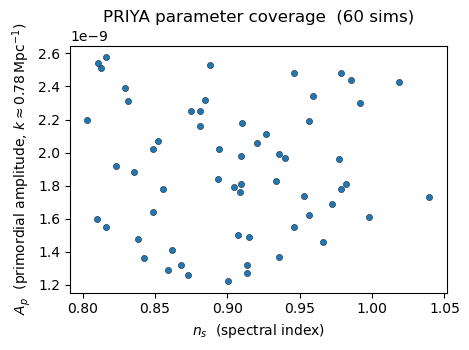

In [2]:
sims = discover_simulations(ROOT)
print("discovered", len(sims), "simulations\n")

p0 = SimParams.from_dir(sims[0].directory)
print("first simulation:")
print("  name      :", p0.name[:60], "...")
print("  box       :", p0.box, "Mpc/h")
print("  npart     :", p0.npart, "  (fidelity:", p0.fidelity, ")")
print("  redshifts :  z_init =", p0.z_init, " ->  z_end =", p0.z_end)

# read (n_s, A_p) for the whole suite. A_p is the folder-name primordial amplitude
# at PRIYA's k = 2*pi/8 ~ 0.78/Mpc pivot (NOT scalar_amp = A_s at k=0.05); the two
# differ by ((2pi/8)/0.05)**(ns-1)  [lya_emulator coarse_grid.py:154-157 @ 27dac4f].
ns, Ap = [], []
for s in sims:
    try:
        p = SimParams.from_dir(s.directory)
        ns.append(p.ns); Ap.append(float(p.name_params["Ap"]))
    except Exception:
        pass
print("\nparameters read for", len(ns), "/", len(sims), "sims")

plt.figure(figsize=(4.8, 3.6))
plt.scatter(ns, Ap, s=20, c="C0", edgecolors="k", linewidths=0.3)
plt.xlabel(r"$n_s$  (spectral index)")
plt.ylabel(r"$A_p$  (primordial amplitude, $k\approx0.78\,$Mpc$^{-1}$)")
plt.title(f"PRIYA parameter coverage  ({len(ns)} sims)")
plt.tight_layout(); plt.show()

## 2. The Lyman-α optical depth `τ`, and the flux `F = exp(−τ)`

`load_tau_grid(path, axis)` returns the **raw** `τ` cube for one line-of-sight
(LOS) axis as a `(ngrid, ngrid, nbins)` array: two transverse indices and one LOS
(velocity) index. It is **redshift-space** (the LOS is a velocity axis,
`vel = velfac·pos + pvel`; `fake_spectra absorption.cpp:234` @ `v2.2.3`) and is
never rebinned — exactly what is stored. Reading needs only `h5py` (no `fake_spectra`).

`F = exp(−τ)` is the transmitted flux: **dark** where `τ` is large (dense gas
filaments absorb the light) and **bright** in the voids. We plot a transverse
slice of `τ`, the same slice of `F`, and a few `τ` skewers along the LOS.

tau cube : (480, 480, 1556)  (ngrid, ngrid, nbins)
redshift : 5.4   box: 120.0 Mpc/h


cube_axes: ('x', 'y', 'z')    <F> (whole cube): 0.095


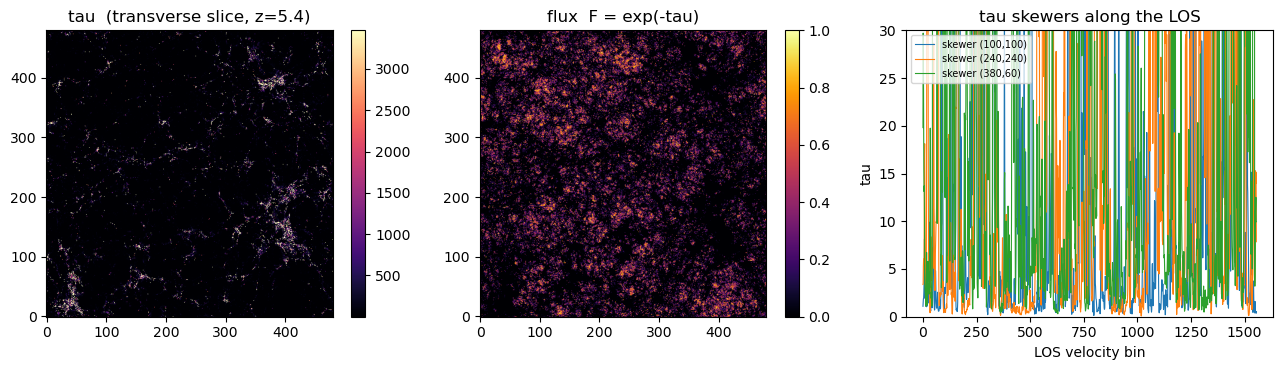

In [3]:
sim = sims[0]
spec = sorted((Path(ROOT) / sim.directory.name / "output").glob("SPECTRA_*"))[0]
fpath = spec / "lya_forest_spectra_grid_480.hdf5"

g = load_tau_grid(fpath, axis=3)        # axis 3: cube_axes = (x, y, z), LOS = z
print("tau cube :", g.tau.shape, " (ngrid, ngrid, nbins)")
print("redshift :", g.redshift, "  box:", g.box, "Mpc/h")
print("cube_axes:", g.cube_axes, "   <F> (whole cube):", round(float(np.exp(-g.tau).mean()), 3))

b = g.nbins // 2
tau_sl  = g.tau[:, :, b]
flux_sl = np.exp(-tau_sl)

fig, ax = plt.subplots(1, 3, figsize=(13, 3.8))
im0 = ax[0].imshow(tau_sl, origin="lower", cmap="magma", vmax=np.percentile(tau_sl, 99))
ax[0].set_title(f"tau  (transverse slice, z={g.redshift})"); fig.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(flux_sl, origin="lower", cmap="inferno", vmin=0, vmax=1)
ax[1].set_title("flux  F = exp(-tau)"); fig.colorbar(im1, ax=ax[1])
for (i, j) in [(100, 100), (240, 240), (380, 60)]:
    ax[2].plot(g.tau[i, j, :], lw=0.8, label=f"skewer ({i},{j})")
ax[2].set_title("tau skewers along the LOS"); ax[2].set_xlabel("LOS velocity bin")
ax[2].set_ylabel("tau"); ax[2].set_ylim(0, 30); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()
del tau_sl, flux_sl

### Mean flux falls with redshift
The mean transmitted flux `⟨F⟩` is a basic check that `τ` is sane: the
high-redshift universe is denser and more neutral, so it absorbs more — `⟨F⟩`
should fall monotonically from ~0.8 near `z≈2.4` toward ~0.1 by `z≈5.4`
(cf. the observed mean-flux evolution, Faucher-Giguère et al. 2008,
[arXiv:0709.2382](https://arxiv.org/abs/0709.2382); Becker et al. 2013,
[arXiv:1208.2584](https://arxiv.org/abs/1208.2584)). This validates the **shape and
sign**, not the absolute level (the sim's UV background is not tuned to observed `⟨F⟩`).

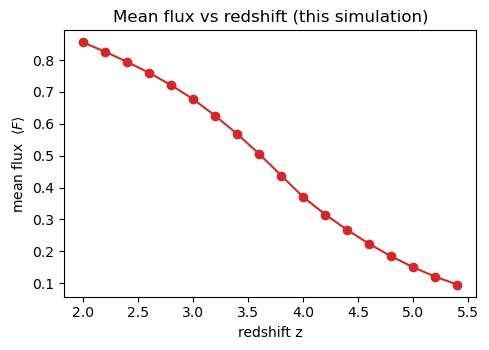

monotonic decreasing: True


In [4]:
specs = sorted((Path(ROOT) / sim.directory.name / "output").glob("SPECTRA_*"))
zs, mfs = [], []
for s in specs:
    f = s / "lya_forest_spectra_grid_480.hdf5"
    if not f.exists():
        continue
    gg = load_tau_grid(f, axis=3)
    zs.append(gg.redshift); mfs.append(float(np.exp(-gg.tau).mean()))
zs, mfs = np.array(zs), np.array(mfs)
o = np.argsort(zs)

plt.figure(figsize=(5.0, 3.6))
plt.plot(zs[o], mfs[o], "o-", c="C3")
plt.xlabel("redshift z"); plt.ylabel(r"mean flux  $\langle F\rangle$")
plt.title("Mean flux vs redshift (this simulation)")
plt.tight_layout(); plt.show()
print("monotonic decreasing:", bool(np.all(np.diff(mfs[o]) <= 1e-6)))

## 3. The initial-condition density `δ₁`

The IC bigfile holds the simulation's starting point at `z≈99`. The native
`ICDensity` block is the **linear overdensity `δ₁`** at each particle's grid
position (white-noise × linear transfer; MP-Gadget `libgenic/zeldovich.c:182,284`
+ `save.c:72` @ `471711f8`) — precisely the field the field-level bias estimator
`β₁(k,μ)=⟨δ_F δ₁*⟩/⟨|δ₁|²⟩` of de Belsunce et al. 2025
([arXiv:2507.00284](https://arxiv.org/abs/2507.00284), Eq. 5) cross-correlates with
the flux. (That paper validates the method on the *Sherwood* sims at `z=2.8`; the
multi-redshift, multi-parameter `b_F(z;θ)` measurement on PRIYA is the follow-up
this loader supports.) `load_ic_density` gives you two views:

| `field=` | what you get | when to use |
|---|---|---|
| `"icdensity"` | the **native linear `δ₁`** on the grid (no painting) | the bias cross-spectrum reference |
| `"cic"` | the **Eulerian** density of the displaced particles, painted with cloud-in-cell | a quick density-field view |

For the `icdensity` route, `nmesh` must **divide** `ngrid` — here the low-res IC is
**512³**, so we use `nmesh=256`. Positions are comoving `kpc/h`; the loader streams
the bigfile so memory stays bounded (`~3·nmesh³` floats).

IC dir: /global/cfs/cdirs/desicollab/users/jibancat/priya/emu_full/ns0.803Ap2.2e-09herei4.05heref2.67alphaq2.21hub0.735omegamh20.141hireionz7.17bhfeedback0.056/ICS/120_512_99 
exists: True



icdensity delta_1: (256, 256, 256)  space: real  mean: -1.52e-06  std: 0.055
cic       overden: (256, 256, 256)  mean: 0.00e+00  min: -0.233  std: 0.050


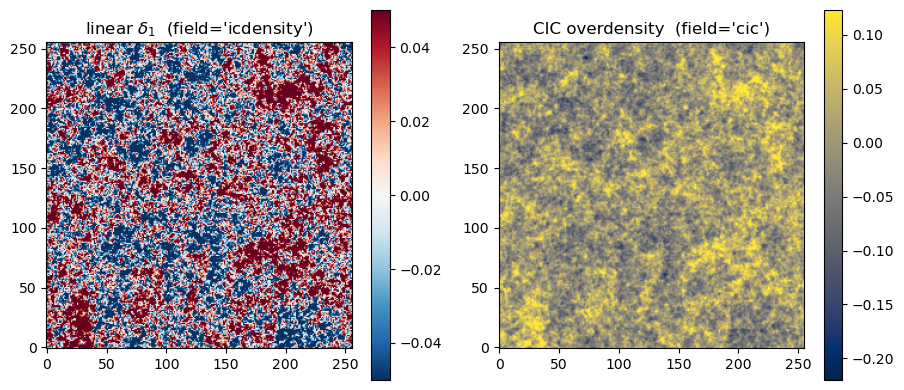

In [5]:
ICDIR = Path(ROOT) / sim.directory.name / "ICS" / "120_512_99"   # low-res = 512^3
print("IC dir:", ICDIR, "\nexists:", ICDIR.is_dir())

lin = load_ic_density(ICDIR, ptype="dm", nmesh=256, field="icdensity")  # native linear delta_1
cic = load_ic_density(ICDIR, ptype="dm", nmesh=256, field="cic")        # Eulerian CIC

print("\nicdensity delta_1:", lin.delta.shape, " space:", lin.space,
      " mean: %.2e  std: %.3f" % (lin.delta.mean(), lin.delta.std()))
print("cic       overden:", cic.delta.shape,
      " mean: %.2e  min: %.3f  std: %.3f" % (cic.delta.mean(), cic.delta.min(), cic.delta.std()))

k = lin.delta.shape[2] // 2
fig, ax = plt.subplots(1, 2, figsize=(9.2, 4.0))
im0 = ax[0].imshow(lin.delta[:, :, k], origin="lower", cmap="RdBu_r",
                   vmin=-0.05, vmax=0.05)
ax[0].set_title(r"linear $\delta_1$  (field='icdensity')"); fig.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(cic.delta[:, :, k], origin="lower", cmap="cividis",
                   vmax=np.percentile(cic.delta, 99))
ax[1].set_title("CIC overdensity  (field='cic')"); fig.colorbar(im1, ax=ax[1])
plt.tight_layout(); plt.show()

**The two IC views trace the same cosmic web.** At `z≈99` the particles have
barely moved (sub-cell **1LPT Zel'dovich** displacements, no 2LPT; MP-Gadget
`libgenic/zeldovich.c:243-245` @ `471711f8`), so the linear `δ₁` and the Eulerian
CIC field are almost the same structure — a strong correlation (here `r≈0.87`; the
CIC window pulls it a little below 1) is the quick check that the Lagrangian index
decode is right.

In [6]:
a = (lin.delta - lin.delta.mean()).ravel()
b = (cic.delta - cic.delta.mean()).ravel()
r = float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))
print("icdensity <-> cic correlation at z~99:  r = %.4f  (expect >~ 0.85)" % r)

icdensity <-> cic correlation at z~99:  r = 0.8674  (expect >~ 0.85)


## 4. `PriyaDataset` — the headline loop

Iterating a `PriyaDataset` yields `Sample(params, redshift, ic, tau)` lazily, one
`(sim, z)` at a time. It is **graceful on partial data**: a simulation with no
staged `τ` is skipped, and a missing IC yields `ic=None` (a τ-only sample).

> **Heads-up on the IC field.** By default `PriyaDataset` looks for the
> **production-resolution** IC (1536³ low-res / 3072³ hi-res — Bird et al. 2023,
> [arXiv:2306.05471](https://arxiv.org/abs/2306.05471) — read from the run
> config). On the NERSC staging used here only the **512³ companion** is present,
> so `s.ic` comes back **`None`** below — a τ-only sample (graceful degradation).
> To work with the staged field today, use the explicit
> `load_ic_density(.../ICS/120_512_99, …)` from §3; `s.ic` auto-populates once the
> production IC is transferred.

`.export(outdir)` writes one self-describing `.npz` per `(sim, z)` for a downstream
pipeline — we don't call it here (it writes files), but that is the one-liner that
turns the suite into an ML-ready dataset on disk.

In [7]:
import warnings
ds = PriyaDataset(ROOT, ic_nmesh=256, ic_field="icdensity", flux_axis=3)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    s = next(iter(ds))                       # first (sim, z): real tau + real IC on NERSC
print("Sample:")
print("  params  :", s.params.name[:48], "...")
print("  redshift:", s.redshift)
print("  ic      :", None if s.ic is None else s.ic.shape, "(linear delta_1)")
print("  tau     :", None if s.tau is None else s.tau.shape)
print("  as_tuple length:", len(s.as_tuple()), " -> [params, z, ic, tau]")
del s

Sample:
  params  : ns0.803Ap2.2e-09herei4.05heref2.67alphaq2.21hub0 ...
  redshift: 5.4
  ic      : None (linear delta_1)
  tau     : (480, 480, 1556)
  as_tuple length: 4  -> [params, z, ic, tau]


## 5. From loaded cubes to the flux bias `b_F` — the consumer's job

The loader only *loads*. To measure the Lyman-α flux bias
`b_F = P_{F,δ₁} / P_{δ₁δ₁}` (de Belsunce et al. 2025, arXiv:2507.00284, Eq. 5) you
still have to:

- **rescale** `δ₁` from `z_init≈99` to the flux redshift by the growth factor
  `D(z_flux)/D(99)` (`units.growth_factor`; Eisenstein 1997,
  [arXiv:astro-ph/9709054](https://arxiv.org/abs/astro-ph/9709054)). This is large
  (~×30) and is *why* a raw, un-rescaled cross-correlation looks much bigger than
  the physical `b_F`.
- **co-register** the cubes. The `τ` axis here is `axis=3`, whose
  `cube_axes=(x,y,z)` is the identity (`fake_spectra griddedspectra.py:42-60` @
  `v2.2.3`); **axes 1 and 2 are permuted**, so transpose
  `δ₁` to `g.cube_axes` before crossing or the cross term averages to zero. Match
  the transverse grid (paint `field="cic"` at `nmesh=480`, or Fourier-match the
  low-`k` modes for `field="icdensity"`).
- **deconvolve** the IC window (CIC `sinc²`, or the `icdensity` block-average `sinc`).
- choose the **mean-flux** normalization and the **DLA/HCD** treatment.

The cell below is a *sign-only sanity proxy* (not the physical `b_F`): project both
fields along the LOS and correlate. A **negative** flux bias `b_F<0` is the
established result (McDonald 2003, [arXiv:astro-ph/0108064](https://arxiv.org/abs/astro-ph/0108064);
Slosar et al. 2011, [arXiv:1104.5244](https://arxiv.org/abs/1104.5244)). The growth
factor `R = D(z)/D(99)` is printed so you can see the amplitude it carries.

In [8]:
# sign-only proxy: transverse-projected cross-correlation (NOT the physical b_F)
g0 = load_tau_grid(specs[int(np.argmin(zs))] / "lya_forest_spectra_grid_480.hdf5", axis=3)
nmesh = g0.tau.shape[0]                                   # 480, to match the tau transverse grid
d1 = load_ic_density(ICDIR, ptype="dm", nmesh=nmesh, field="cic").delta
F = np.exp(-g0.tau); dF = F / F.mean() - 1.0
av = d1.mean(2) - d1.mean()                              # project IC along LOS
bv = dF.mean(2) - dF.mean()                              # project flux along LOS
b_proxy = float((av * bv).sum() / (av * av).sum())

p = SimParams.from_dir(sim.directory)                    # this sim's cosmology
om, ol = p.omega0, p.omega_lambda                        # flat LCDM: omega_lambda = 1 - omega0
R = units.growth_factor(g0.redshift, om, ol) / units.growth_factor(99.0, om, ol)
print("z = %.2f" % g0.redshift)
print("growth factor  R = D(z)/D(99) = %.1f" % R)
print("transverse-projected proxy  b_proxy = %+.3f   (sign < 0 = anti-correlation, as expected)" % b_proxy)
print("=> the NEGATIVE sign is the meaningful result; the magnitude is inflated by R and is")
print("   only a proxy. The rigorous mu-dependent b_F is in HANDOFF.md.")

z = 2.00
growth factor  R = D(z)/D(99) = 32.7
transverse-projected proxy  b_proxy = -1.632   (sign < 0 = anti-correlation, as expected)
=> the NEGATIVE sign is the meaningful result; the magnitude is inflated by R and is
   only a proxy. The rigorous mu-dependent b_F is in HANDOFF.md.


## 6. Recap & where to go next

You loaded, from the **real** PRIYA suite, with no MP-Gadget expertise required:

- **§1** every simulation's parameters (`SimParams`) and the suite's design grid;
- **§2** the raw `τ` cube and flux `F=exp(−τ)`, with the mean-flux–vs-`z` check;
- **§3** the IC density `δ₁` two ways (`icdensity` linear, `cic` Eulerian);
- **§4** the `PriyaDataset` loop yielding `[params, z, ic, τ]`;
- **§5** the growth/co-registration steps that turn those cubes into `b_F`.

**Next:** `ds.export("<scratch>/priya_npz")` to materialize the dataset as `.npz`,
or read `HANDOFF.md` for the rigorous `b_F = P_{F,δ₁}/P_{δ₁δ₁}` recipe. To run on a
different machine, change only `ROOT` / `$PRIYA_ROOT` — nothing is hard-coded.

**Provenance.** Every simulation convention, unit, and constant used in this
notebook is traced to its upstream source at a pinned git commit in
[`PROVENANCE.md`](../PROVENANCE.md).